<a href="https://colab.research.google.com/github/somendrew/LangGraph_tutorial/blob/main/5_Conditional_edges.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. What is it?
A conditional edge is an edge that doesn't always go to the same next node. Instead, it runs a function that looks at the state and decides where to go next. Think of it as an if/else inside your graph's wiring.

## 2. Why does it matter?
So far our graph always goes A → B → C. But real apps need to make decisions:

Is this message rude? → route to escalation</br>
Did the LLM produce a good answer? → route to format, or retry</br>
Is the user a premium customer? → route to priority support</br>

Without conditional edges you'd have one rigid path. With them, your graph becomes a real decision-making system.

## 3. The Analogy
Think of an airport security lane:

Everyone goes through the scanner (a regular node)</br>
Then a guard looks at the result and decides:

* All clear → Gate (one path)
* Needs check → Secondary screening (another path)
* Flagged → Supervisor (third path)



The guard's decision IS the conditional edge — same input point, different destinations based on what they see.

## 4.Visuals

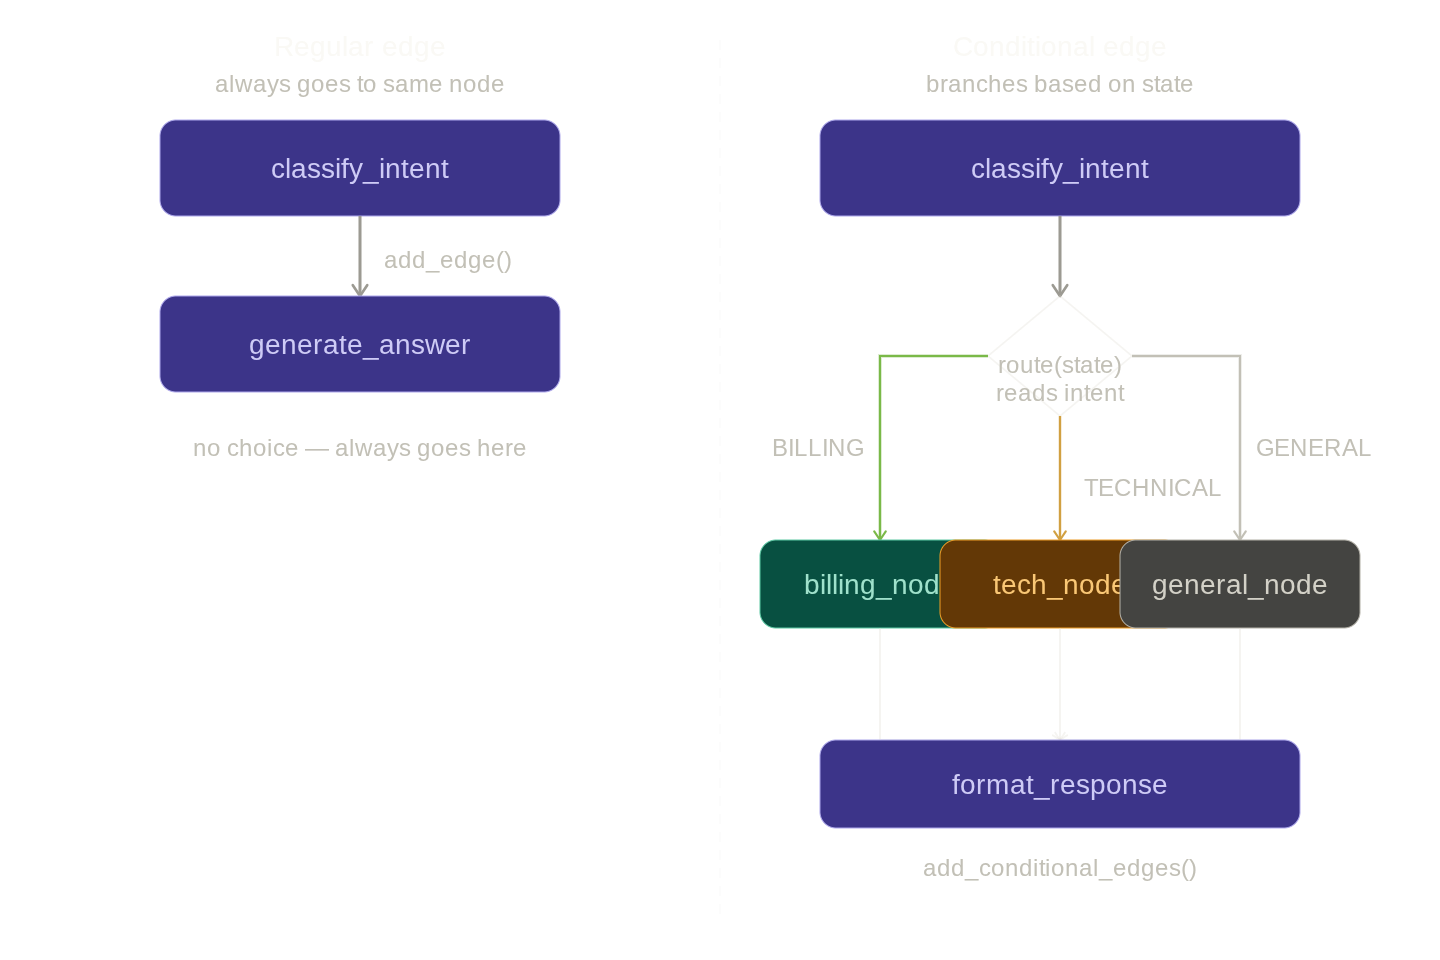





In [2]:
!pip install -q langchain_openai langgraph typing langchain_core

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 27.6 MB/s eta 0:00:00


In [3]:
from google.colab import userdata
api_key = userdata.get('api_key')

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


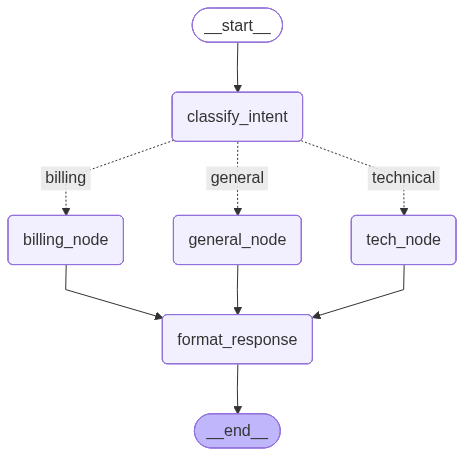

In [4]:
import os
from typing import TypedDict, Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

llm = ChatOpenAI(model="gpt-4o-mini", api_key = api_key, temperature=0)

# ── 1. State (same as before) ─────────────────────────────
class SupportState(TypedDict):
    user_message: str
    intent:       str
    response:     str
    messages:     Annotated[list, add_messages]

# ── 2. Node 1: Classify (same as before) ─────────────────
def classify_intent(state: SupportState) -> dict:
    prompt = f"""Classify this message into exactly one word:
BILLING, TECHNICAL, or GENERAL.
Message: {state['user_message']}"""
    result = llm.invoke(prompt)
    intent = result.content.strip().upper()
    return {"intent": intent}

# ── 3. NEW: Three specialist nodes instead of one ─────────

def billing_node(state: SupportState) -> dict:
    """Handles billing-specific questions with billing context."""
    prompt = f"""You are a billing specialist.
Help with this billing issue: {state['user_message']}
Mention you can process refunds and check payment history."""
    result = llm.invoke(prompt)
    return {
        "response": result.content,
        "messages": [AIMessage(content=result.content)],
    }

def tech_node(state: SupportState) -> dict:
    """Handles technical questions with debugging context."""
    prompt = f"""You are a technical support engineer.
Help debug this issue: {state['user_message']}
Ask for OS version and steps to reproduce."""
    result = llm.invoke(prompt)
    return {
        "response": result.content,
        "messages": [AIMessage(content=result.content)],
    }

def general_node(state: SupportState) -> dict:
    """Handles general questions."""
    prompt = f"""You are a helpful support agent.
Answer this general question: {state['user_message']}"""
    result = llm.invoke(prompt)
    return {
        "response": result.content,
        "messages": [AIMessage(content=result.content)],
    }

# ── 4. Format node (same as before) ──────────────────────
def format_response(state: SupportState) -> dict:
    sign_offs = {
        "BILLING":   "— Billing Team",
        "TECHNICAL": "— Tech Support",
        "GENERAL":   "— Support Team",
    }
    sign_off  = sign_offs.get(state["intent"], "— Support Team")
    formatted = f"{state['response']}\n\n{sign_off}"
    return {"response": formatted}

# ── 5. NEW: The router function ───────────────────────────
def route_by_intent(state: SupportState) -> str:
    """
    Reads state['intent'] and returns a string key.
    LangGraph uses this key to look up the next node.
    This function never calls nodes — it only returns a string.
    """
    intent = state["intent"].upper()
    if intent == "BILLING":
        return "billing"
    elif intent == "TECHNICAL":
        return "technical"
    else:
        return "general"

# ── 6. Build the graph ────────────────────────────────────
builder = StateGraph(SupportState)

# Register all nodes
builder.add_node("classify_intent", classify_intent)
builder.add_node("billing_node",    billing_node)    # NEW
builder.add_node("tech_node",       tech_node)       # NEW
builder.add_node("general_node",    general_node)    # NEW
builder.add_node("format_response", format_response)

# Regular edge: START → classify
builder.add_edge(START, "classify_intent")

# NEW: Conditional edge — after classify, call route_by_intent
# and use its return value to pick the next node
builder.add_conditional_edges(
    "classify_intent",   # from this node
    route_by_intent,     # call this router function
    {                    # map return value → node name
        "billing":   "billing_node",
        "technical": "tech_node",
        "general":   "general_node",
    }
)

# All three specialist nodes converge back to format
builder.add_edge("billing_node",  "format_response")  # NEW
builder.add_edge("tech_node",     "format_response")  # NEW
builder.add_edge("general_node",  "format_response")  # NEW
builder.add_edge("format_response", END)

app = builder.compile()

# ── 7. Visualize ──────────────────────────────────────────
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

# ── 8. Test all three paths ───────────────────────────────
def run(msg):
    print(f"\nUser: {msg}")
    print("─" * 40)
    result = app.invoke({
        "user_message": msg,
        "intent":       "",
        "response":     "",
        "messages":     [HumanMessage(content=msg)],
    })
    print(f"\n{result['response']}\n")


In [5]:

run("I was charged twice for my subscription!")
run("The app crashes when I export a file.")
run("What are your opening hours?")


User: I was charged twice for my subscription!
────────────────────────────────────────

I’m sorry to hear that you were charged twice for your subscription. I can definitely help you with this issue. I can check your payment history to confirm the charges and process a refund for the duplicate payment if necessary. 

Could you please provide me with your account details or the email associated with your subscription? This will help me assist you more efficiently.

— Billing Team


User: The app crashes when I export a file.
────────────────────────────────────────

Sure! To help you debug the issue with the app crashing during file export, I need a bit more information. Could you please provide the following details?

1. What operating system (OS) are you using, and what version is it?
2. Can you describe the exact steps you take to reproduce the crash? For example, what type of file are you trying to export, and are there any specific settings or options you select before exporting?